In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_20newsgroups

categories = [
    "alt.atheism",
    "talk.religion.misc",
    "comp.graphics",
    "sci.space",
]

dataset = fetch_20newsgroups(
    remove=("headers", "footers", "quotes"),
    subset="all",
    categories=categories,
    shuffle=True,
    random_state=42,
)

labels = dataset.target
unique_labels, category_sizes = np.unique(labels, return_counts=True)
true_k = unique_labels.shape[0]

print(f"{len(dataset.data)} documents - {true_k} categories")

3387 documents - 4 categories


In [2]:
data = pd.DataFrame({"posts": dataset.data, "label": dataset.target} )
data

,posts,label
0,My point is that you set up your views as the ...,0
1,\nBy '8 grey level images' you mean 8 items of...,1
2,FIRST ANNUAL PHIGS USER GROUP CONFERENCE\n\n ...,1
3,"I responded to Jim's other articles today, but...",3
4,"\nWell, I am placing a file at my ftp today th...",1
...,...,...
3382,I am working on a program to display 3d wirefr...,1
3383,\n Did the Russian spacecraft(s) on the ill-f...,2
3384,"\n\nOh gee, a billion dollars! That'd be just...",2
3385,I am looking for software to run on my brand n...,1


In [3]:
import nltk

nltk.download('stopwords')
nltk.download('words')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/hoaibao174/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package words to /home/hoaibao174/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package punkt to /home/hoaibao174/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/hoaibao174/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/hoaibao174/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [4]:
import re

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')

stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Bước 1: Chuyển kiểu viết thường
    result = text.lower()

    # Bước 2: Xoá noisy words (number, punctuation, special chars, html,...) bằng Regular Expression.
    result = re.sub(r'\d+', '', result)
    result = re.sub(r'<\/?\w+>', ' ', result)
    result = re.sub(r'\s+', ' ', result)
    result = re.sub(r'[^\w\s]', '', result)

    # Bước 3: Tách từ (tokenization)
    tokens = nltk.word_tokenize(result)

    # Bước 4: Xoá các từ dừng (stopwords)
    tokens = [token for token in tokens if token not in stop_words]

    # Bước 5: Stemming & Lemmatization
    tokens = [lemmatizer.lemmatize(token) for token in tokens]

    return ' '.join(tokens)

def preprocess_data(row):
    row = row.astype(str).apply(preprocess_text)
    return row

[nltk_data] Downloading package wordnet to
[nltk_data]     /home/hoaibao174/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [6]:
data['processed'] = preprocess_data(data['posts'])
data

,posts,label,processed
0,My point is that you set up your views as the ...,0,point set view way believe saying eveil world ...
1,\nBy '8 grey level images' you mean 8 items of...,1,grey level image mean item bit image work does...
2,FIRST ANNUAL PHIGS USER GROUP CONFERENCE\n\n ...,1,first annual phigs user group conference first...
3,"I responded to Jim's other articles today, but...",3,responded jims article today see neglected res...
4,"\nWell, I am placing a file at my ftp today th...",1,well placing file ftp today contains several p...
...,...,...,...
3382,I am working on a program to display 3d wirefr...,1,working program display wireframe model user a...
3383,\n Did the Russian spacecraft(s) on the ill-f...,2,russian spacecraft illfated phobos mission yea...
3384,"\n\nOh gee, a billion dollars! That'd be just...",2,oh gee billion dollar thatd enough cover cost ...
3385,I am looking for software to run on my brand n...,1,looking software run brand new targa anyone kn...


In [7]:
from sklearn.model_selection import train_test_split

X = data['processed']
label = data['label']

X_train, X_test, Y_train, Y_test = train_test_split(X, label, test_size = 0.2, random_state = 64)

In [ ]:
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

# User-defined function transformer
preprocessor = FunctionTransformer(preprocess_data)
vectorizer = TfidfVectorizer()
classifier = MultinomialNB()

steps = [
    ("preprocessing", preprocessor),
    ("vectorize", vectorizer),
    ("classify", classifier),
]

model = Pipeline(steps)
model.fit(X_train, Y_train)

In [9]:
from sklearn.metrics import accuracy_score

Y_train_predict = model.predict(X_train)
print("Train accuracy: ", accuracy_score(Y_train, Y_train_predict))

Y_test_predict = model.predict(X_test)
print("Test accuracy: ", accuracy_score(Y_test, Y_test_predict))

Train accuracy:  0.9010705057216685
Test accuracy:  0.803834808259587


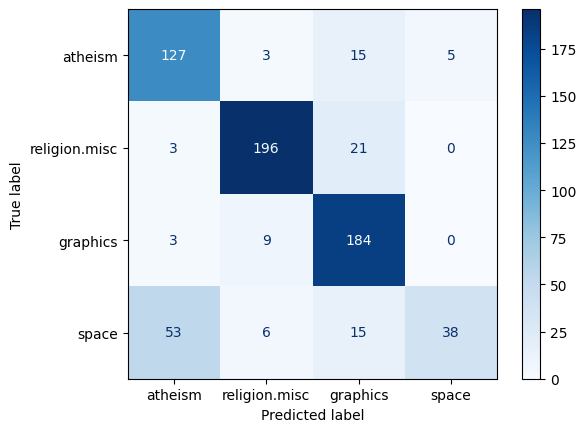

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

classes = [
    "atheism",
    "religion.misc",
    "graphics",
    "space"
]
cm = confusion_matrix(y_true=Y_test, y_pred=Y_test_predict)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Blues")

In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Test Precision: ", precision_score(Y_test, Y_test_predict, average='weighted'))
print("Test Recall: ", recall_score(Y_test, Y_test_predict, average='weighted'))
print("Test F1 score: ", f1_score(Y_test, Y_test_predict, average='weighted'))

Test Precision:  0.8205829733256549
Test Recall:  0.803834808259587
Test F1 score:  0.7881548843986905


### Inference

In [15]:
post_1 = "Hey friend, let's have some beer tonight. sound good?"
post_2 = "We offer you a free coupon to buy this machine with just 200 dollar in cash"

df_posts = pd.DataFrame({'posts': [post_1, post_2]})

model.predict(df_posts['posts'])

array([2, 2])